# Time-Frequency — worked examples

The companion notebook to the [Time-Frequency
manual](../../docs/manuals/time-frequency.md). Same three examples, same
demo files, same numbers — computed here in a few lines of
`spwb.processing` instead of clicked in the application.

The manual carries the explanations and the history; this notebook is where
you change a parameter and watch what happens. Nothing here imports Qt, so
it runs anywhere `pip install spwb[io]` runs.

### Three ways to use this, needing progressively more

1. **Read it.** GitHub renders this file with every graph and number
   already in place. Nothing to install, nothing to run.
2. **Run it as a script** — no Jupyter involved at all:
   `python examples/manuals/time_frequency.py`
3. **Run it cell by cell** in VS Code or Jupyter: change the block size,
   the overlap, the window, and watch the trade play out.

For (3), VS Code will ask which kernel to use. **Choose the Python
interpreter you installed SPWB into** — the same one `pip install -e .`
was run with. There is no separate "spwb" environment unless you created
one yourself. If it is not offered, run `pip install ipykernel` into it
and reopen the notebook.

| Section | Demo file | Shows |
|---|---|---|
| 1 | `12_TFA_Sweeps_linear_and_log.h5` | Sweeps as diagonals, linear against logarithmic |
| 2 | `12_TFA_Sweeps_linear_and_log.h5` | Gabor's trade: block size against both axes |
| 3 | `13_TFA_Tone_bursts.h5` | The cursor's two sections, and the bin grid |

Every section ends with an `assert` on the numbers the manual quotes.

## Setup

The demo datasets are generated rather than committed — they are 21 MB, and
`spwb.demo` reproduces them exactly from a fixed seed. The cell below
creates them if they are missing, so there is nothing to download. The
application offers the same thing under **File > Create Demo Data ...**.

In [1]:
from pathlib import Path

import numpy as np

try:                                    # notebook: draw figures inline
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:                       # plain script: draw to a buffer
    import matplotlib
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def demo_folder() -> Path:
    """Where the demonstration datasets live.

    A git checkout keeps them in its own untracked ``.data/``. Anyone who
    installed the wheel has no checkout and gets them beside wherever they
    are working instead. Either way ``spwb.demo`` writes them on demand.
    """
    here = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
    for folder in (here, *here.parents):
        if (folder / "pyproject.toml").is_file() and (folder / "src").is_dir():
            return folder / ".data"
    return Path.cwd() / "spwb-demo-data"


DATA = demo_folder()

if not any(DATA.glob("[0-9][0-9]_*.h5")):
    from spwb.demo import write_demo_data

    print(f"creating the demonstration datasets in {DATA} ...")
    write_demo_data(DATA)

print(f"datasets : {len(list(DATA.glob('*.h5')))} files in {DATA}")

datasets : 14 files in <your pySPWB checkout>\.data


In [2]:
from spwb.processing.dsp.timefreq import stft_spectrogram
from spwb.processing.io import read_hdf5


def load(filename: str) -> dict:
    """Every signal in a demo file, keyed by name."""
    return {s.name: s for s in read_hdf5(DATA / filename)}


def spectrogram(signal, *, block=1024, overlap=0.75, window="hanning",
                normalize=False):
    """One spectrogram, with overlap expressed as the panel expresses it."""
    return stft_spectrogram(signal, block_size=block,
                            hop=max(1, int(round(block * (1 - overlap)))),
                            window=window, normalize=normalize)


def ridge(spec):
    """The loudest bin in every frame - the sweep's track."""
    return spec.freqs[np.argmax(spec.data, axis=1)]


def draw(spec, ax, *, title="", ylim=(0, 2500), dynamic_range=100.0):
    """The spectrogram as the window draws it: dB, time across, frequency up."""
    db = spec.to_db(dynamic_range=dynamic_range)
    ax.imshow(db.data.T, origin="lower", aspect="auto", cmap="turbo",
              extent=[spec.times[0], spec.times[-1],
                      spec.freqs[0], spec.freqs[-1]])
    ax.set(xlabel="Time (s)", ylabel="Frequency (Hz)", ylim=ylim, title=title)
    return db


print("ready")

ready


## 1. A sweep is a diagonal

**File:** `12_TFA_Sweeps_linear_and_log.h5` — a tone sweeping 20 Hz to
2000 Hz over 20 s, linearly; and the same endpoints swept logarithmically.

Manual: [Worked example
1](../../docs/manuals/time-frequency.md#worked-example-1--a-sweep-is-a-diagonal).

In [3]:
sweeps = load("12_TFA_Sweeps_linear_and_log.h5")
linear = sweeps["Linear sweep 20 to 2000 Hz"]
logarithmic = sweeps["Logarithmic sweep 20 to 2000 Hz"]

spec = spectrogram(linear)
print(f"  {spec.n_frames} x {spec.n_bins} (time x frequency)   "
      f"df = {spec.df:g} Hz, dt = {spec.dt * 1e3:g} ms")
print(f"  time {spec.times[0]:g} .. {spec.times[-1]:g} s, "
      f"frequency {spec.freqs[0]:g} .. {spec.freqs[-1]:g} Hz")

track = ridge(spec)
print(f"\n  {'t (s)':>7} {'peak bin':>10} {'expected':>10} {'error':>8}")
for at in (0.0, 2.5, 5.0, 10.0, 15.0, 19.0):
    i = int(np.argmin(np.abs(spec.times - at)))
    want = 20 + (2000 - 20) * spec.times[i] / 20.0
    print(f"  {spec.times[i]:7.2f} {track[i]:10.1f} {want:10.1f} "
          f"{track[i] - want:8.1f}")

slope, intercept = np.polyfit(spec.times, track, 1)
print(f"\n  straight-line fit through every frame: {slope:.2f} Hz/s, "
      f"intercept {intercept:.1f} Hz")
print(f"  the file says 20 -> 2000 Hz in 20 s, i.e. {(2000 - 20) / 20:.1f} Hz/s")
print(f"  every error above is under half a bin (df/2 = {spec.df / 2:g} Hz), "
      "which is\n  the best any peak-bin reading can do")

  641 x 512 (time x frequency)   df = 8 Hz, dt = 31.25 ms
  time 0 .. 20 s, frequency 0 .. 4088 Hz

    t (s)   peak bin   expected    error
     0.00       24.0       20.0      4.0
     2.50      264.0      267.5     -3.5
     5.00      512.0      515.0     -3.0
    10.00     1008.0     1010.0     -2.0
    15.00     1504.0     1505.0     -1.0
    19.00     1904.0     1901.0      3.0

  straight-line fit through every frame: 99.00 Hz/s, intercept 20.0 Hz
  the file says 20 -> 2000 Hz in 20 s, i.e. 99.0 Hz/s
  every error above is under half a bin (df/2 = 4 Hz), which is
  the best any peak-bin reading can do


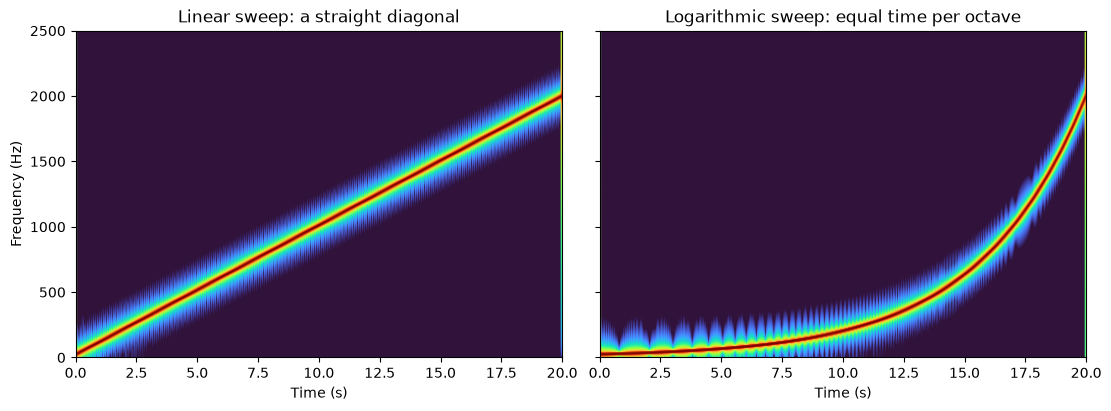

    t (s)    linear       log
      0.0      24.0      24.0
      2.5     264.0      32.0
      5.0     512.0      64.0
     10.0    1008.0     200.0
     15.0    1504.0     632.0
     19.0    1904.0    1592.0

  same start, same end, completely different journey - which is why the log
  sweep is the standard acoustic measurement signal: equal effort per octave


In [4]:
spec_log = spectrogram(logarithmic)
track_log = ridge(spec_log)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4), sharey=True,
                                  constrained_layout=True)
draw(spec, left, title="Linear sweep: a straight diagonal")
draw(spec_log, right, title="Logarithmic sweep: equal time per octave")
right.set_ylabel("")
plt.show()

print(f"  {'t (s)':>7} {'linear':>9} {'log':>9}")
for at in (0.0, 2.5, 5.0, 10.0, 15.0, 19.0):
    i = int(np.argmin(np.abs(spec.times - at)))
    j = int(np.argmin(np.abs(spec_log.times - at)))
    print(f"  {at:7.1f} {track[i]:9.1f} {track_log[j]:9.1f}")
print("\n  same start, same end, completely different journey - which is why "
      "the log\n  sweep is the standard acoustic measurement signal: equal "
      "effort per octave")

In [5]:
assert abs(slope - 99.0) < 1.0, slope
assert abs(intercept - 20.0) < 6.0, intercept
for at in (2.5, 10.0, 19.0):
    i = int(np.argmin(np.abs(spec.times - at)))
    want = 20 + 99.0 * spec.times[i]
    assert abs(track[i] - want) <= spec.df / 2 + 1e-9, (at, track[i], want)
assert track_log[int(np.argmin(np.abs(spec_log.times - 10.0)))] < 400
print(f"section 1 OK - the ridge tracks {slope:.2f} Hz/s against a true 99.0, "
      "every point inside half a bin")

section 1 OK - the ridge tracks 99.00 Hz/s against a true 99.0, every point inside half a bin


## 2. The trade you cannot avoid

One control sets the resolution of *both* axes, in opposite directions.
Gabor proved in 1946 that this is a property of what a frequency means, not
a limitation of the method.

Manual: [Worked example
2](../../docs/manuals/time-frequency.md#worked-example-2--the-trade-you-cannot-avoid).

In [6]:
print(f"  {'block':>6} {'df (Hz)':>9} {'dt (ms)':>9} {'block (ms)':>11} "
      f"{'frames':>7} {'bins':>6} {'df x block':>11}")
for block in (128, 256, 512, 1024, 2048, 4096, 8192):
    sp = spectrogram(linear, block=block)
    seconds = block / linear.fs
    print(f"  {block:6d} {sp.df:9.3f} {sp.dt * 1e3:9.3f} {seconds * 1e3:11.1f} "
          f"{sp.n_frames:7d} {sp.n_bins:6d} {sp.df * seconds:11.4f}")
print("\n  the last column is 1.0000 in every row - that IS the uncertainty "
      "relation")

   block   df (Hz)   dt (ms)  block (ms)  frames   bins  df x block
     128    64.000     3.906        15.6    5121     64      1.0000
     256    32.000     7.812        31.2    2561    128      1.0000
     512    16.000    15.625        62.5    1281    256      1.0000
    1024     8.000    31.250       125.0     641    512      1.0000
    2048     4.000    62.500       250.0     321   1024      1.0000
    4096     2.000   125.000       500.0     161   2048      1.0000
    8192     1.000   250.000      1000.0      81   4096      1.0000

  the last column is 1.0000 in every row - that IS the uncertainty relation


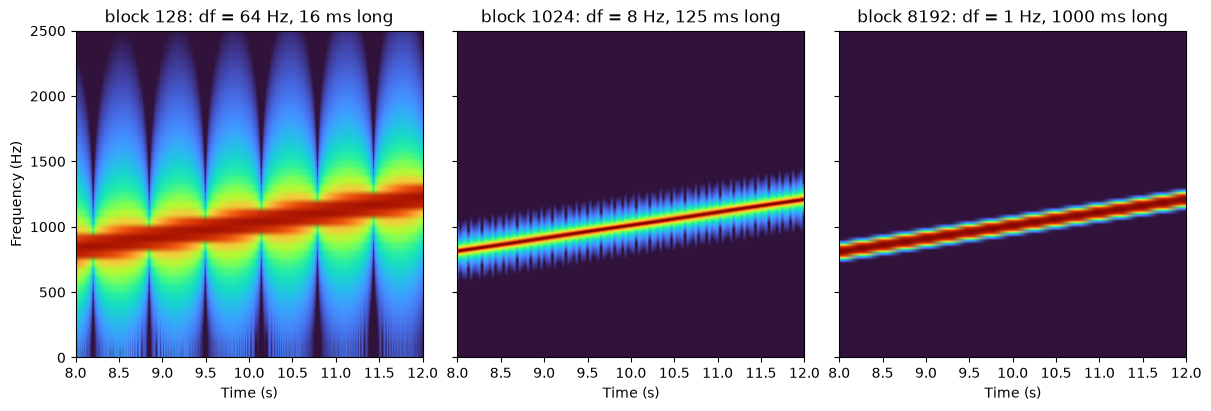

  zoomed to 8-12 s. Short blocks: thin in time, coarse in frequency.
  Long blocks: fine in frequency, but each frame averages a second of a signal
  whose frequency moves 99 Hz in that time - so the tone is genuinely spread.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True,
                         constrained_layout=True)
for ax, block in zip(axes, (128, 1024, 8192), strict=True):
    sp = spectrogram(linear, block=block)
    draw(sp, ax, title=f"block {block}: df = {sp.df:g} Hz, "
                       f"{block / linear.fs * 1e3:.0f} ms long")
    ax.set_xlim(8, 12)
for ax in axes[1:]:
    ax.set_ylabel("")
plt.show()
print("  zoomed to 8-12 s. Short blocks: thin in time, coarse in frequency.")
print("  Long blocks: fine in frequency, but each frame averages a second of "
      "a signal\n  whose frequency moves 99 Hz in that time - so the tone is "
      "genuinely spread.")

**Overlap is not a substitute.** It gives more frames of the same block
length: the picture is smoother, but no sharper.

In [8]:
bursts = load("13_TFA_Tone_bursts.h5")["Four overlapping tone bursts"]
print(f"  {'overlap':>8} {'hop':>6} {'frames':>8} {'block length':>13}")
for over in (0.0, 0.5, 0.75, 0.90):
    sp = spectrogram(bursts, block=1024, overlap=over)
    print(f"  {over * 100:7.0f}% {sp.attributes['TFA_Hop']:6d} "
          f"{sp.n_frames:8d} {1024 / bursts.fs * 1e3:12.0f} ms")

   overlap    hop   frames  block length
        0%   1024      129          125 ms
       50%    512      257          125 ms
       75%    256      513          125 ms
       90%    102     1286          125 ms


In [9]:
for block in (128, 1024, 8192):
    sp = spectrogram(linear, block=block)
    assert abs(sp.df * (block / linear.fs) - 1.0) < 1e-9, block
    assert sp.n_bins == block // 2
    assert abs(sp.df - linear.fs / block) < 1e-9
print("section 2 OK - df x block length = 1.0000 exactly at every block size")

section 2 OK - df x block length = 1.0000 exactly at every block size


## 3. The cursor, and reading a value off the picture

**File:** `13_TFA_Tone_bursts.h5` — four tones switching on and off with
overlaps: 100 Hz from 1-4 s, 400 Hz from 3-7 s, 900 Hz from 6-10 s,
1600 Hz from 9-14 s.

Manual: [Worked example
3](../../docs/manuals/time-frequency.md#worked-example-3--the-cursor-and-reading-a-value-off-the-picture).

In [10]:
PLAN = ((100.0, 1.0, 4.0), (400.0, 3.0, 7.0),
        (900.0, 6.0, 10.0), (1600.0, 9.0, 14.0))

spec_b = spectrogram(bursts)
db = spec_b.to_db(dynamic_range=100.0)
print(f"  {spec_b.n_frames} x {spec_b.n_bins}, df = {spec_b.df:g} Hz, "
      f"dt = {spec_b.dt * 1e3:g} ms, display {db.data.min():.0f} .. "
      f"{db.data.max():.0f} dB")

print("\n  which tones does the Time Section find alive at each instant?")
print(f"  {'t (s)':>7}  {'above -40 dB':24} {'actually on':24}")
for at in (0.5, 2.0, 3.5, 6.5, 9.5, 12.0, 15.0):
    section = db.time_section(at)
    found = [f"{f:g}" for f, _s, _e in PLAN
             if section.y[int(np.argmin(np.abs(spec_b.freqs - f)))] > -40]
    truly = [f"{f:g}" for f, start, stop in PLAN if start <= at < stop]
    assert found == truly, (at, found, truly)
    print(f"  {at:7.1f}  {', '.join(found) or 'none':24} "
          f"{', '.join(truly) or 'none':24}")
print("\n  every row matches the file's plan")

  513 x 512, df = 8 Hz, dt = 31.25 ms, display -100 .. 0 dB

  which tones does the Time Section find alive at each instant?
    t (s)  above -40 dB             actually on             
      0.5  none                     none                    
      2.0  100                      100                     
      3.5  100, 400                 100, 400                
      6.5  400, 900                 400, 900                
      9.5  900, 1600                900, 1600               
     12.0  1600                     1600                    
     15.0  none                     none                    

  every row matches the file's plan


In [11]:
section = db.time_section(3.5)
over_time = db.frequency_section(400.0)

print(f"  Time Section      {section.name!r}")
print(f"  Frequency Section {over_time.name!r}\n")
print("  the headline check - at t = 3.5 s the Time Section shows TWO peaks:")
for f in (100.0, 400.0, 900.0, 1600.0):
    j = int(np.argmin(np.abs(spec_b.freqs - f)))
    print(f"    {f:6g} Hz (bin {spec_b.freqs[j]:6.1f}) -> {section.y[j]:8.2f} dB")

alive = over_time.t[over_time.y > -40]
print(f"\n  Frequency Section at 400 Hz: above -40 dB from {alive.min():.3f} s "
      f"to {alive.max():.3f} s\n  (the file says 3 to 7 s; the ~31 ms of "
      "overshoot is the 125 ms block\n  starting to see the tone before it "
      "formally begins)")

  Time Section      'Four overlapping tone bursts @ 3.5 s'
  Frequency Section 'Four overlapping tone bursts @ 400 Hz'

  the headline check - at t = 3.5 s the Time Section shows TWO peaks:
       100 Hz (bin   96.0) ->    -1.42 dB
       400 Hz (bin  400.0) ->    -0.00 dB
       900 Hz (bin  896.0) ->  -100.00 dB
      1600 Hz (bin 1600.0) ->  -100.00 dB

  Frequency Section at 400 Hz: above -40 dB from 2.969 s to 7.031 s
  (the file says 3 to 7 s; the ~31 ms of overshoot is the 125 ms block
  starting to see the tone before it formally begins)


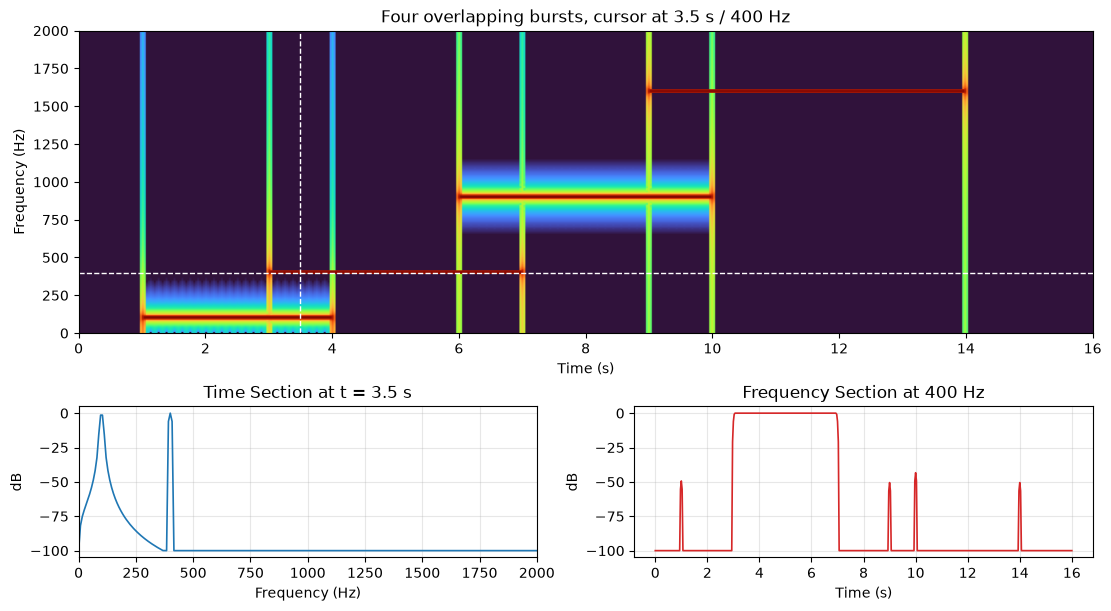

In [12]:
fig = plt.figure(figsize=(11, 6), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[2, 1])
top = fig.add_subplot(grid[0, :])
draw(spec_b, top, title="Four overlapping bursts, cursor at 3.5 s / 400 Hz",
     ylim=(0, 2000))
top.axvline(3.5, color="w", lw=1, ls="--")
top.axhline(400, color="w", lw=1, ls="--")

left = fig.add_subplot(grid[1, 0])
left.plot(section.t, section.y, lw=1.2)
left.set(xlabel="Frequency (Hz)", ylabel="dB", xlim=(0, 2000), ylim=(-105, 5),
         title="Time Section at t = 3.5 s")
left.grid(True, alpha=0.3)

right = fig.add_subplot(grid[1, 1])
right.plot(over_time.t, over_time.y, lw=1.2, color="tab:red")
right.set(xlabel="Time (s)", ylabel="dB", ylim=(-105, 5),
          title="Frequency Section at 400 Hz")
right.grid(True, alpha=0.3)
plt.show()

### Why 100 Hz reads -1.42 dB and 400 Hz reads 0.00

Both tones have the same amplitude. But with `df = 8 Hz` the bins are
0, 8, 16 … 96, 104 — and **100 Hz falls exactly halfway between two of
them**, so its energy is split. 400 Hz is a multiple of 8 and lands dead
centre.

This is the scalloping loss from the [FFT
manual](../../docs/manuals/fft-analysis.md), in different units: a Hanning
window under-reads a half-bin-off tone to 0.849 of its amplitude, and
10·log₁₀(0.849²) is -1.42 dB.

In [13]:
print(f"  {'tone':>7} {'nearest bin':>12} {'offset':>8}   on the grid?")
for f, _s, _e in PLAN:
    j = int(np.argmin(np.abs(spec_b.freqs - f)))
    print(f"  {f:6g} Hz {spec_b.freqs[j]:11.1f} {spec_b.freqs[j] - f:+8.1f}   "
          f"{'yes' if abs(spec_b.freqs[j] - f) < 1e-9 else 'NO - splits'}")

print(f"\n  scalloping in dB: 10*log10(0.84883^2) = "
      f"{10 * np.log10(0.84883 ** 2):.2f} dB")

print("\n  and the fix - block 2048 makes df = 4 Hz, which does divide 100:")
finer = spectrogram(bursts, block=2048).to_db(dynamic_range=100.0)
finer_freqs = spectrogram(bursts, block=2048).freqs
for f in (100.0, 400.0):
    j8 = int(np.argmin(np.abs(spec_b.freqs - f)))
    j4 = int(np.argmin(np.abs(finer_freqs - f)))
    i4 = int(np.argmin(np.abs(finer.times - 3.5)))
    print(f"    {f:6g} Hz:  df=8 bin {spec_b.freqs[j8]:6.1f} -> "
          f"{section.y[j8]:6.2f} dB   |   df=4 bin {finer_freqs[j4]:6.1f} -> "
          f"{finer.data[i4, j4]:6.2f} dB")

     tone  nearest bin   offset   on the grid?
     100 Hz        96.0     -4.0   NO - splits
     400 Hz       400.0     +0.0   yes
     900 Hz       896.0     -4.0   NO - splits
    1600 Hz      1600.0     +0.0   yes

  scalloping in dB: 10*log10(0.84883^2) = -1.42 dB

  and the fix - block 2048 makes df = 4 Hz, which does divide 100:
       100 Hz:  df=8 bin   96.0 ->  -1.42 dB   |   df=4 bin  100.0 ->  -0.00 dB
       400 Hz:  df=8 bin  400.0 ->  -0.00 dB   |   df=4 bin  400.0 ->  -0.00 dB


**And one last honest detail: Norm Signal changes the numbers, not the
picture.** It scales the signal to unit peak, dividing every power value by
the peak squared — but the dB display is relative to each record's own
peak, so the image is identical.

In [14]:
plain = spectrogram(bursts)
normed = spectrogram(bursts, normalize=True)
peak = float(np.max(np.abs(bursts.y)))
print(f"  signal peak {peak:.6f},  peak^2 = {peak ** 2:.6f}")
print(f"  max power: plain {plain.data.max():.6g}, normed {normed.data.max():.6g}, "
      f"ratio {plain.data.max() / normed.data.max():.6f}")
print(f"  identical once converted to dB: "
      f"{np.allclose(plain.to_db().data, normed.to_db().data)}")

  signal peak 1.996307,  peak^2 = 3.985241
  max power: plain 0.16669, normed 0.0418269, ratio 3.985241
  identical once converted to dB: True


In [15]:
j100 = int(np.argmin(np.abs(spec_b.freqs - 100.0)))
j400 = int(np.argmin(np.abs(spec_b.freqs - 400.0)))
assert abs(section.y[j400]) < 0.01, section.y[j400]
assert abs(section.y[j100] - (-1.42)) < 0.05, section.y[j100]
assert abs(spec_b.freqs[j100] - 96.0) < 1e-9, "100 Hz must land off the grid"
assert 2.9 < alive.min() < 3.05 and 6.95 < alive.max() < 7.1
assert np.allclose(plain.to_db().data, normed.to_db().data)
print(f"section 3 OK - 400 Hz reads {section.y[j400]:.2f} dB on the grid, "
      f"100 Hz reads {section.y[j100]:.2f} dB off it")

section 3 OK - 400 Hz reads -0.00 dB on the grid, 100 Hz reads -1.42 dB off it


## Where to go next

* The [Time-Frequency manual](../../docs/manuals/time-frequency.md) — the
  same three examples driven through the application, plus the history from
  Gabor's 1946 time-frequency plane to the Bell Labs sound spectrograph.
* The other manuals and their notebooks:
  [`time_processing.py`](time_processing.py),
  [`fft_analysis.py`](fft_analysis.py),
  [`transfer_function.py`](transfer_function.py).
* `python tools/verify_demo_data.py` — the assertions that keep the demo
  datasets honest.

`spec.data` is a plain NumPy array of shape (frames, bins), so anything you
would do to an image — thresholding, ridge tracking, summing bands — works
on it directly. `ridge()` at the top of this notebook is four words of
NumPy and it tracked the sweep to within half a bin.